In [83]:
import pandas as pd 
import numpy as np

from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler

# import ipympl 
# %matplotlib ipympl


file_path = '../Dataset/preprocessed_combined_data_weekday_3-2022_3-2023.csv'

df = pd.read_csv(file_path)

df.set_index('Date Time', inplace=True)

display(df)

,kW,Nantum,Season,Altimeter reading,DP Temp (F),DB Temp (F),Heat_day,Cool_day,DP_12h,DB_12h,DP_24h,DB_24h,Weekday_0,Weekday_1,Weekday_2,Weekday_3,Weekday_4,Weekday_5,Weekday_6
Date Time,,,,,,,,,,,,,,,,,,,
2022-03-24 00:00:00,121.500,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,1,0,0,0
2022-03-24 00:15:00,121.500,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,1,0,0,0
2022-03-24 00:30:00,119.248,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,1,0,0,0
2022-03-24 00:45:00,120.600,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,1,0,0,0
2022-03-24 01:00:00,123.300,0,0,30.11,16.0,56,0.093750,0.000000,12.0,74.0,23.0,58.0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-22 22:45:00,117.448,1,0,30.03,34.0,49,0.166667,0.000000,26.0,57.0,38.0,46.0,0,0,1,0,0,0,0
2023-03-22 23:00:00,115.200,1,0,30.03,34.0,50,0.156250,0.000000,24.0,57.0,38.0,45.0,0,0,1,0,0,0,0
2023-03-22 23:15:00,118.348,1,0,30.03,34.0,50,0.156250,0.000000,24.0,57.0,38.0,45.0,0,0,1,0,0,0,0


In [84]:
df =df[['kW']]

df.index = pd.to_datetime(df.index)

mask = (df.index.month >= 7) & (df.index.month < 8)  # July / 1 month

df_july = df[mask]

df.reset_index(drop=False, inplace=True)
df_july.reset_index(drop=False, inplace=True)

display(df)

display(df_july)

,Date Time,kW
0,2022-03-24 00:00:00,121.500
1,2022-03-24 00:15:00,121.500
2,2022-03-24 00:30:00,119.248
3,2022-03-24 00:45:00,120.600
4,2022-03-24 01:00:00,123.300
...,...,...
34938,2023-03-22 22:45:00,117.448
34939,2023-03-22 23:00:00,115.200
34940,2023-03-22 23:15:00,118.348
34941,2023-03-22 23:30:00,116.100


,Date Time,kW
0,2022-07-01 00:00:00,126.000
1,2022-07-01 00:15:00,142.200
2,2022-07-01 00:30:00,121.500
3,2022-07-01 00:45:00,120.152
4,2022-07-01 01:00:00,119.248
...,...,...
2971,2022-07-31 22:45:00,115.200
2972,2022-07-31 23:00:00,112.948
2973,2022-07-31 23:15:00,108.000
2974,2022-07-31 23:30:00,111.152


**ADF TEST**

We'll use the Augmented Dickey Fuller (ADF) test to check if the energy series is stationary

The null hypothesis of the ADF test is that the time series is non-stationary. So, if the p-value of the test is less than the significance level (0.05) then we can reject the null hypothesis and infer that the time series indeed stationary

So, in our case, if the p-value > 0.05 we'll need to find the order of differencing

In [85]:
from statsmodels.tsa.stattools import adfuller
from numpy import log

result = adfuller(df.kW.dropna())
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])


ADF Statistic: -18.891942
p-value: 0.000000


In [86]:
result_july = adfuller(df_july.kW.dropna())
print('ADF Statistic: %f' % result_july[0])
print('p-value: %f' % result_july[1])

ADF Statistic: -7.227020
p-value: 0.000000


**According to the ADF test, the data appears to be stationary**

Statistical properties of time series such as mean, variance should remain constant over time to call time series is stationary
- constant mean
- constant variance
- autocovariance that does not depend on time. autocovariance is covariance between time series and lagged time series.

We can use the pmdarima package to get the number of differencing. (To double check)

In [87]:
from pmdarima.arima.utils import ndiffs

ndiffs(df.kW, test='adf')

0

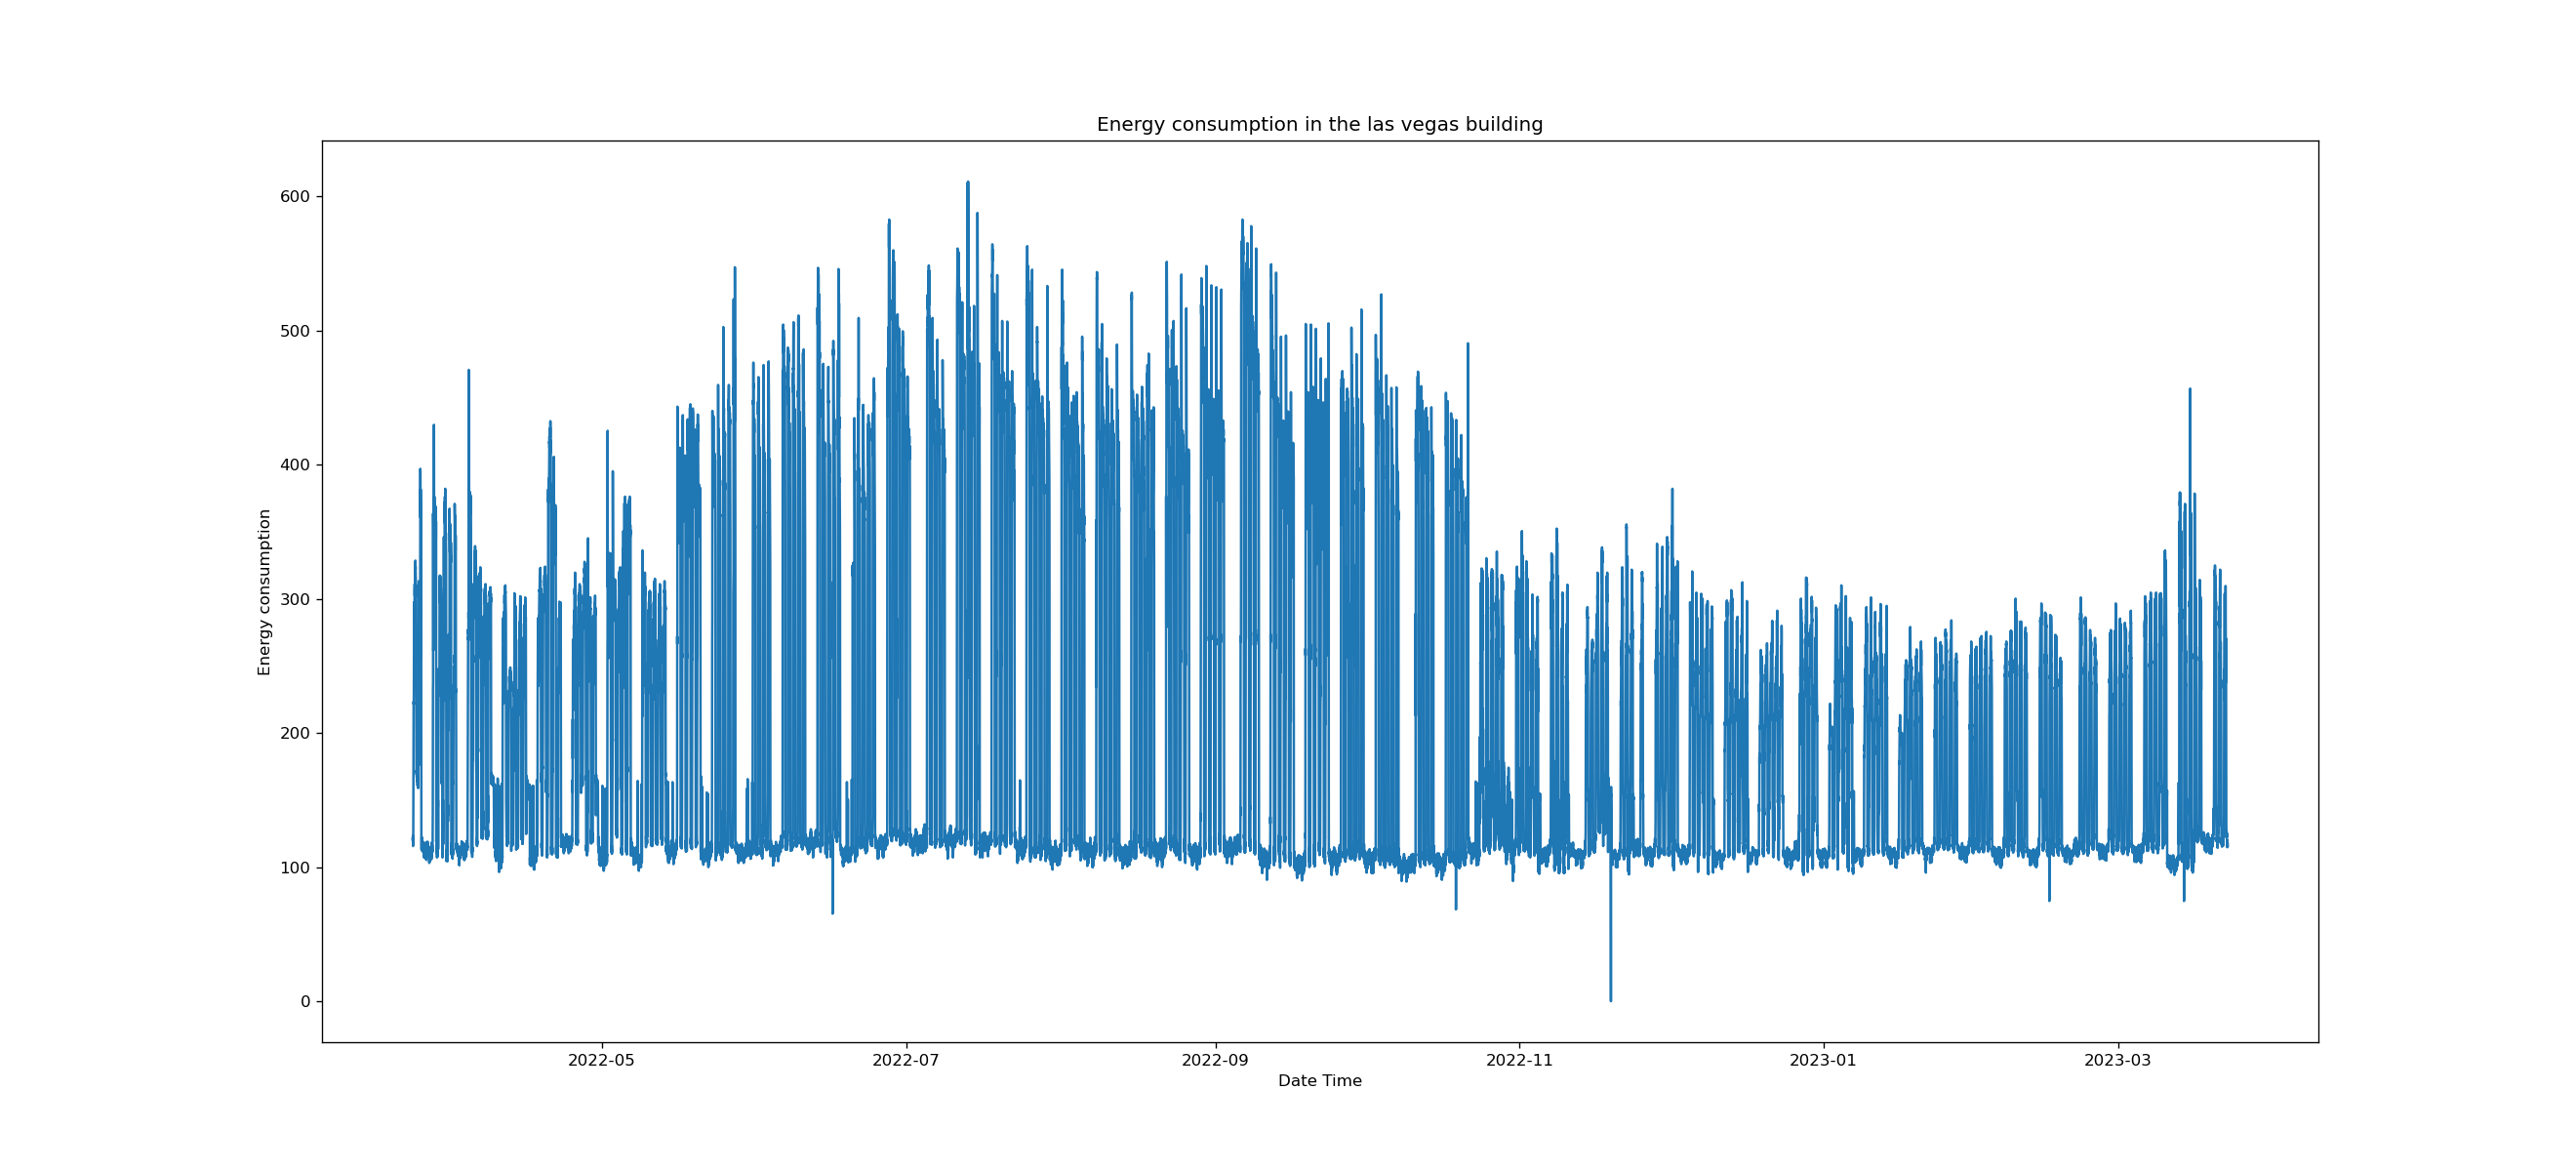

,kW
Date Time,
2022-03-24 00:00:00,121.500
2022-03-24 00:15:00,121.500
2022-03-24 00:30:00,119.248
2022-03-24 00:45:00,120.600
2022-03-24 01:00:00,123.300
...,...
2023-03-22 22:45:00,117.448
2023-03-22 23:00:00,115.200
2023-03-22 23:15:00,118.348


In [88]:
# Energy consumption in the Las Vegas building

plt.figure(figsize=(22,10))
plt.plot(df['Date Time'], df['kW'])
plt.title("Energy consumption in the las vegas building")
plt.xlabel("Date Time")
plt.ylabel("Energy consumption")
plt.show()

# lets create time series from weather 
timeSeries = df.loc[:, ["Date Time","kW"]]
timeSeries.index = timeSeries['Date Time']
ts = timeSeries.drop("Date Time",axis=1)

display(ts)

**P**

p is the order of the Auto Regressive (AR) ter. It refers to the number of lags to be used as predictors

We can find out the required number of AR terms by inspecting the **Partial Autocorrelation (PACF) plot**

The partial autocorrelation represents the correlation between the series and its lags

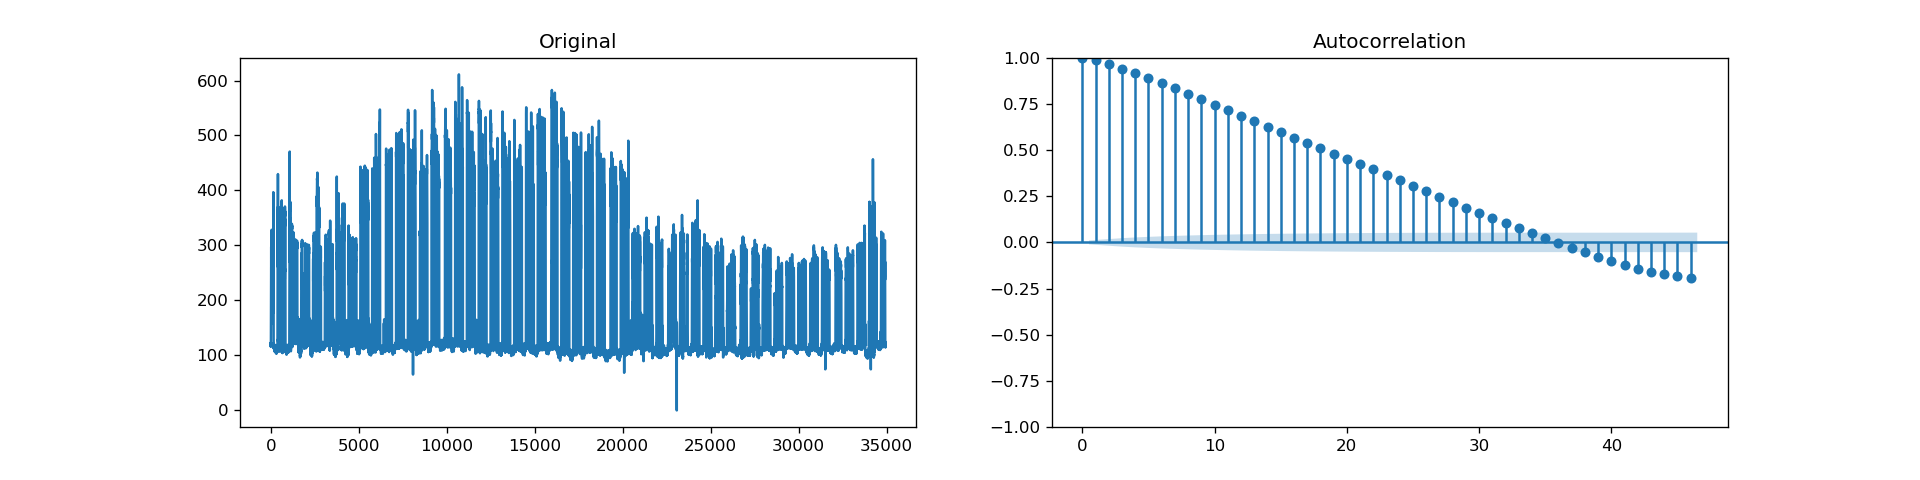

In [89]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,4))

ax1.plot(df.kW)
ax1.set_title('Original')
ax2.set_ylim(0,1)

plot_acf(df.kW, ax=ax2);



P = 0

**q**

q is the order of the Moving Average (MA) term. It refers tot the number of lagged forecast errors that should go into the ARIMA model

We can look at the ACF plot for the number of MA terms

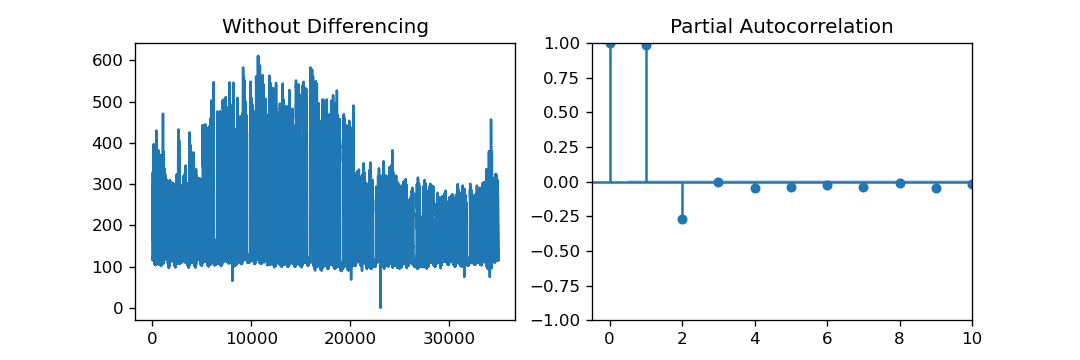

In [90]:
# PACF plot of 1st differenced series
plt.rcParams.update({'figure.figsize':(9,3), 'figure.dpi':120})

fig, axes = plt.subplots(1, 2, sharex=False)
axes[0].plot(df.kW)
axes[0].set_title('Without Differencing')

axes[1].set(ylim=(0,5))
plot_pacf(df.kW.dropna(), ax=axes[1])
axes[1].set_xlim(-0.5, 10) 




plt.show()

In [91]:
from statsmodels.tsa.arima.model import ARIMA as ARIMA

model = ARIMA(df['kW'],order = (0,0,0))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                     kW   No. Observations:                34943
Model:                          ARIMA   Log Likelihood             -217532.487
Date:                Wed, 21 Feb 2024   AIC                         435068.973
Time:                        15:50:40   BIC                         435085.896
Sample:                             0   HQIC                        435074.364
                              - 34943                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        198.7823      1.112    178.722      0.000     196.602     200.962
sigma2      1.496e+04    191.137     78.247      0.000    1.46e+04    1.53e+04
Ljung-Box (L1) (Q):               33932.37   Jarque-